<a href="https://colab.research.google.com/github/HinnaNayab/DeepLearning/blob/Applied-AI/Tutorial_3_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras import regularizers

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [2]:
# MNIST load dataset

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

print("Training images:", x_train.shape)
print("Training labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


In [3]:
# Normalizing pixel values and one-hot encode labels

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Pixel range after normalization:", x_train.min(), "to", x_train.max())
print("Example label:", y_train[0])
print("One-hot label:", y_train_cat[0])

Pixel range after normalization: 0.0 to 1.0
Example label: 5
One-hot label: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


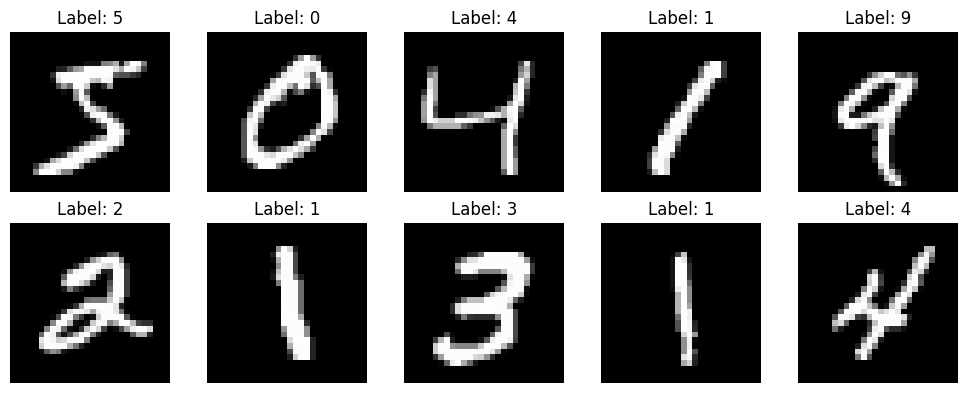

In [4]:
# visualizing a few images

plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Building the model
model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# compiling the model

model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [7]:
# training the original model

history = model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9240 - loss: 0.2593 - val_accuracy: 0.9579 - val_loss: 0.1362
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9673 - loss: 0.1092 - val_accuracy: 0.9667 - val_loss: 0.1126
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9769 - loss: 0.0744 - val_accuracy: 0.9682 - val_loss: 0.1075
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9816 - loss: 0.0569 - val_accuracy: 0.9708 - val_loss: 0.1010
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9850 - loss: 0.0455 - val_accuracy: 0.9718 - val_loss: 0.1010
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9886 - loss: 0.0352 - val_accuracy: 0.9715 - val_loss: 0.1028
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9901 - loss: 0.0298 - val_accuracy: 0.9756 - val_loss: 0.0887
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9918 - loss: 0.0240 -

In [8]:
# evaluating on the unseen test set

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test_cat,
    verbose=0
)

print("Test loss:", test_loss)
print("Test accuracy:", test_accuracy)

Test loss: 0.09002421796321869
Test accuracy: 0.9772999882698059


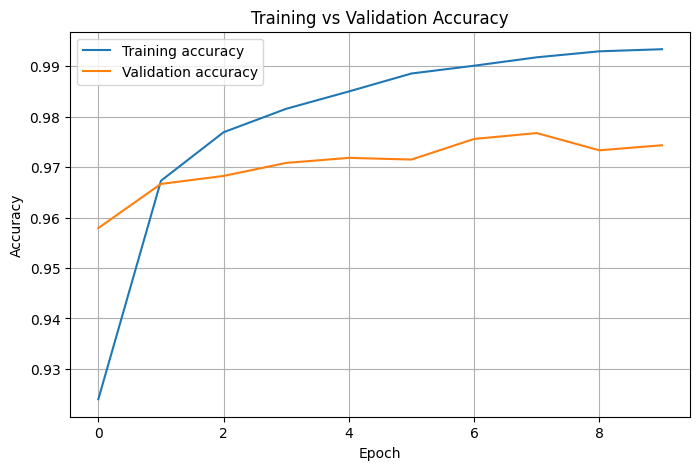

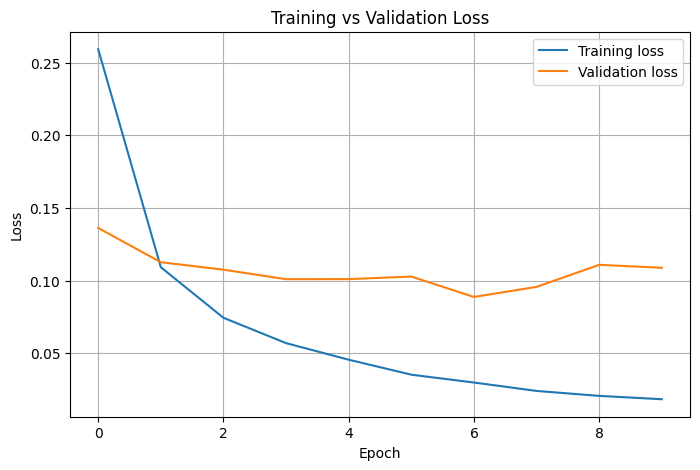

In [9]:
# plotting training and validation accuracy/loss

plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"], label="Training accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

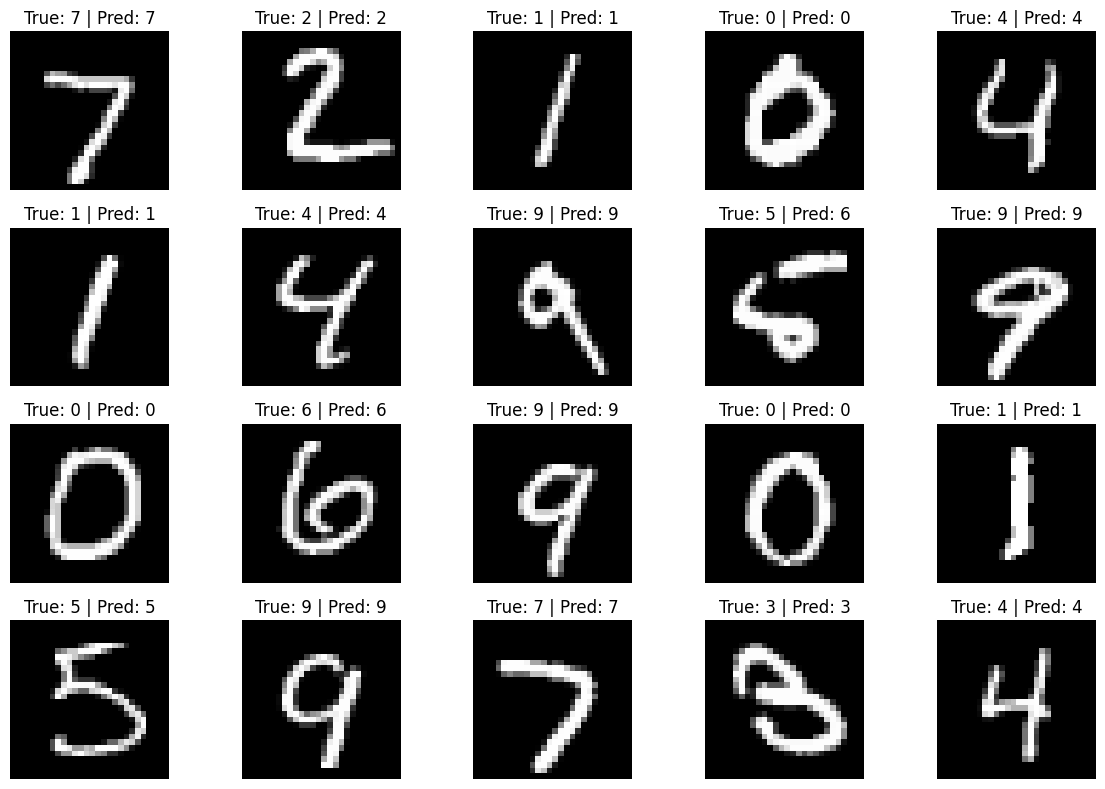

In [10]:
# making predictions and visualize examples

pred_probs = model.predict(x_test[:20], verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

plt.figure(figsize=(12, 8))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(x_test[i], cmap="gray")
    plt.title(f"True: {y_test[i]} | Pred: {pred_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [11]:
# TASK 1 — Function to build an ANN with different architectures

def build_model(hidden_layers=(128, 64), activation="relu"):
    model = Sequential()
    model.add(Flatten(input_shape=(28, 28)))

    for units in hidden_layers:
        model.add(Dense(units, activation=activation))

    model.add(Dense(10, activation="softmax"))

    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
# TASK 1A — Compare several architectures/activations

architecture_configs = {
    "Original ReLU 128-64": ((128, 64), "relu"),
    "Larger ReLU 256-128-64": ((256, 128, 64), "relu"),
    "Smaller ReLU 64-32": ((64, 32), "relu"),
    "Tanh 128-64": ((128, 64), "tanh"),
    "Sigmoid 128-64": ((128, 64), "sigmoid")
}

architecture_results = []

for name, (layers, activation) in architecture_configs.items():
    tf.keras.backend.clear_session()

    m = build_model(hidden_layers=layers, activation=activation)
    h = m.fit(
        x_train, y_train_cat,
        epochs=5,
        batch_size=32,
        validation_split=0.20,
        verbose=0
    )

    loss, acc = m.evaluate(x_test, y_test_cat, verbose=0)

    architecture_results.append({
        "Model": name,
        "Test Accuracy": acc,
        "Test Loss": loss,
        "Final Train Accuracy": h.history["accuracy"][-1],
        "Final Validation Accuracy": h.history["val_accuracy"][-1]
    })

architecture_results_df = pd.DataFrame(architecture_results)
display(architecture_results_df)

,Model,Test Accuracy,Test Loss,Final Train Accuracy,Final Validation Accuracy
0,Original ReLU 128-64,0.9702,0.103743,0.986146,0.969167
1,Larger ReLU 256-128-64,0.9752,0.087268,0.986521,0.973500
2,Smaller ReLU 64-32,0.9734,0.091026,0.978292,0.970833
3,Tanh 128-64,0.9735,0.082945,0.984500,0.973917
4,Sigmoid 128-64,0.9707,0.095255,0.976042,0.968833


In [13]:
# TASK 2 — Compare SGD, RMSprop and Adam

optimizer_results = []
optimizers = {
    "SGD": tf.keras.optimizers.SGD(learning_rate=0.01),
    "RMSprop": tf.keras.optimizers.RMSprop(learning_rate=0.001),
    "Adam": tf.keras.optimizers.Adam(learning_rate=0.001)
}

for name, optimizer in optimizers.items():
    tf.keras.backend.clear_session()

    m = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    m.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    h = m.fit(
        x_train, y_train_cat,
        epochs=5,
        batch_size=32,
        validation_split=0.20,
        verbose=0
    )

    loss, acc = m.evaluate(x_test, y_test_cat, verbose=0)

    optimizer_results.append({
        "Optimizer": name,
        "Test Accuracy": acc,
        "Test Loss": loss,
        "Final Train Accuracy": h.history["accuracy"][-1],
        "Final Validation Accuracy": h.history["val_accuracy"][-1]
    })

optimizer_results_df = pd.DataFrame(optimizer_results)
display(optimizer_results_df)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


,Optimizer,Test Accuracy,Test Loss,Final Train Accuracy,Final Validation Accuracy
0,SGD,0.9424,0.192802,0.943125,0.945750
1,RMSprop,0.9750,0.098349,0.984271,0.975333
2,Adam,0.9752,0.081183,0.985708,0.974250


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


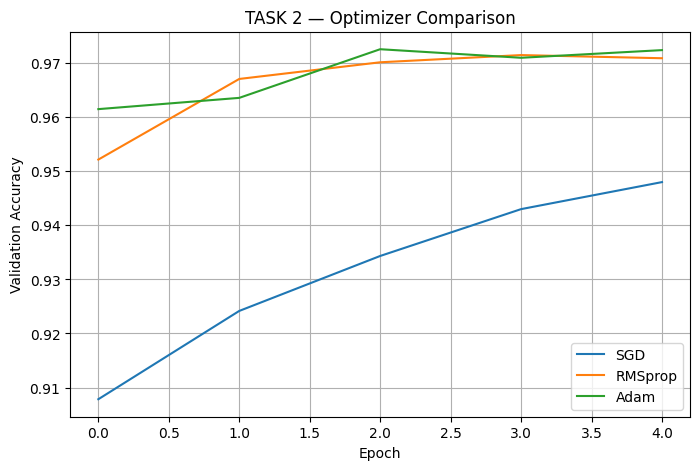

In [16]:
import tensorflow as tf

# TASK 2B — Plot validation accuracy for the three optimizers

plt.figure(figsize=(8, 5))

# Define optimizer configurations, not instantiated objects
optimizer_configs = {
    "SGD": (tf.keras.optimizers.SGD, {"learning_rate": 0.01}),
    "RMSprop": (tf.keras.optimizers.RMSprop, {"learning_rate": 0.001}),
    "Adam": (tf.keras.optimizers.Adam, {"learning_rate": 0.001})
}

for name, (optimizer_class, optimizer_kwargs) in optimizer_configs.items():
    tf.keras.backend.clear_session()

    m = Sequential([
        Flatten(input_shape=(28, 28)),
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(10, activation="softmax")
    ])

    # Instantiate the optimizer inside the loop
    optimizer_instance = optimizer_class(**optimizer_kwargs)

    m.compile(
        optimizer=optimizer_instance,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    h = m.fit(
        x_train, y_train_cat,
        epochs=5,
        batch_size=32,
        validation_split=0.20,
        verbose=0
    )

    plt.plot(h.history["val_accuracy"], label=name)

plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.title("TASK 2 — Optimizer Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
# TASK 3A — Train for more epochs so that the curves can be inspected

tf.keras.backend.clear_session()

model_long = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model_long.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_long = model_long.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9199 - loss: 0.2741 - val_accuracy: 0.9546 - val_loss: 0.1519
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9666 - loss: 0.1108 - val_accuracy: 0.9641 - val_loss: 0.1136
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9766 - loss: 0.0765 - val_accuracy: 0.9691 - val_loss: 0.1001
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9822 - loss: 0.0553 - val_accuracy: 0.9749 - val_loss: 0.0936
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9864 - loss: 0.0441 - val_accuracy: 0.9746 - val_loss: 0.0922
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9879 - loss: 0.0352 - val_accuracy: 0.9755 - val_loss: 0.0988
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9908 - loss: 0.0280 - val_accuracy: 0.9746 - val_loss: 0.1036
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9916 - loss: 0.0254 -

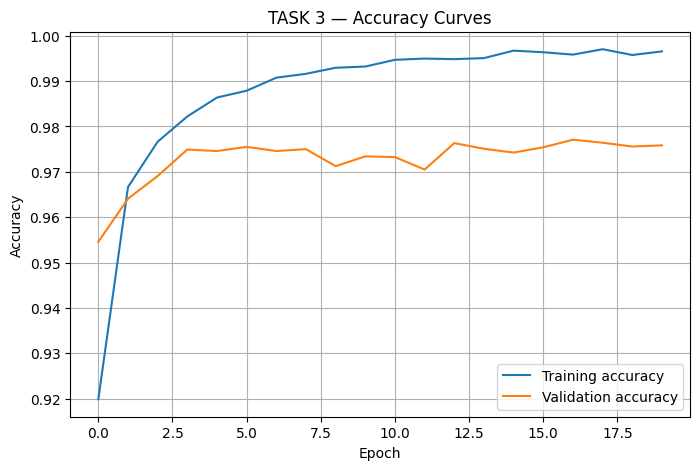

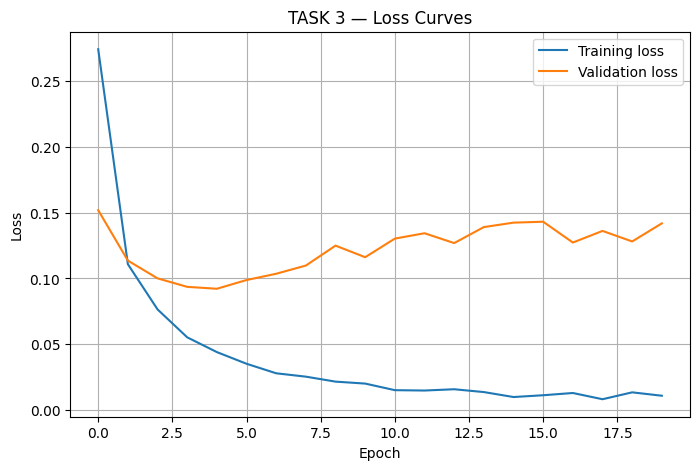

In [18]:
# TASK 3B — Plot curves and inspect overfitting/underfitting

plt.figure(figsize=(8, 5))
plt.plot(history_long.history["accuracy"], label="Training accuracy")
plt.plot(history_long.history["val_accuracy"], label="Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("TASK 3 — Accuracy Curves")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_long.history["loss"], label="Training loss")
plt.plot(history_long.history["val_loss"], label="Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("TASK 3 — Loss Curves")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# TASK 3C — Early Stopping

tf.keras.backend.clear_session()

early_stop_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

early_stop_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

early_history = early_stop_model.fit(
    x_train,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.20,
    callbacks=[early_stopping],
    verbose=1
)

print("Epochs actually completed:", len(early_history.history["loss"]))

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9206 - loss: 0.2670 - val_accuracy: 0.9590 - val_loss: 0.1417
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9665 - loss: 0.1123 - val_accuracy: 0.9676 - val_loss: 0.1074
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9755 - loss: 0.0787 - val_accuracy: 0.9695 - val_loss: 0.1024
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9812 - loss: 0.0595 - val_accuracy: 0.9722 - val_loss: 0.0947
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9854 - loss: 0.0450 - val_accuracy: 0.9775 - val_loss: 0.0864
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9887 - loss: 0.0347 - val_accuracy: 0.9754 - val_loss: 0.0909
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9899 - loss: 0.0307 - val_accuracy: 0.9729 - val_loss: 0.0980
Epochs actually completed: 7


In [20]:
# TASK 3D — Regularization with Dropout

tf.keras.backend.clear_session()

dropout_model = Sequential([
    Flatten(input_shape=(28, 28)),
    Dense(128, activation="relu"),
    Dropout(0.30),
    Dense(64, activation="relu"),
    Dropout(0.30),
    Dense(10, activation="softmax")
])

dropout_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

dropout_history = dropout_model.fit(
    x_train,
    y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.20,
    verbose=1
)

dropout_test_loss, dropout_test_acc = dropout_model.evaluate(
    x_test, y_test_cat, verbose=0
)

print("Dropout model test loss:", dropout_test_loss)
print("Dropout model test accuracy:", dropout_test_acc)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8719 - loss: 0.4271 - val_accuracy: 0.9552 - val_loss: 0.1535
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9376 - loss: 0.2159 - val_accuracy: 0.9649 - val_loss: 0.1203
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9496 - loss: 0.1733 - val_accuracy: 0.9689 - val_loss: 0.1078
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9564 - loss: 0.1452 - val_accuracy: 0.9733 - val_loss: 0.0956
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9619 - loss: 0.1296 - val_accuracy: 0.9747 - val_loss: 0.0914
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9647 - loss: 0.1188 - val_accuracy: 0.9738 - val_loss: 0.0910
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9673 - loss: 0.1102 - val_accuracy: 0.9749 - val_loss: 0.0851
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9686 - loss: 0.1032 - 

In [21]:
# TASK 3E — Final comparison table

original_loss, original_acc = model.evaluate(x_test, y_test_cat, verbose=0)
early_loss, early_acc = early_stop_model.evaluate(x_test, y_test_cat, verbose=0)

comparison = pd.DataFrame({
    "Model": [
        "Original 10-epoch model",
        "Early Stopping model",
        "Dropout model"
    ],
    "Test Accuracy": [
        original_acc,
        early_acc,
        dropout_test_acc
    ],
    "Test Loss": [
        original_loss,
        early_loss,
        dropout_test_loss
    ]
})

display(comparison)

,Model,Test Accuracy,Test Loss
0,Original 10-epoch model,0.9773,0.090024
1,Early Stopping model,0.9745,0.081441
2,Dropout model,0.9772,0.083228
